## Clustering Demographics 

In [1]:
######################## LOAD IN FILES #############################
import os
import pandas as pd
import sys
import importlib
import numpy as np
import pandas as pd
from IPython.display import display
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform


# Get the absolute path of the project root
project_root = os.getcwd()
# Define data directory
brighten_dir = os.path.join(project_root, 'BRIGHTEN_data')

# Add project root to sys.path for script usage
sys.path.append(project_root)

# Import and reload (optional) custom scripts
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import clustering as cl
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(cl)


################ DEFINE column variables from data ###################
from scripts.variables import id_columns, daily_cols_v1, daily_v2_common, df_names
from scripts.variables import phq2_cols, phq9_cols, weekly_cols, passive_cols


print(df_names)

['v1_day', 'v2_day', 'v1_week', 'v2_week']


In [106]:
# Read in DFs and create demo_df
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

dfs = {}
dfs['phq9_baseline'] = pd.read_csv(os.path.join(brighten_dir,'PHQ-9 - Baseline.csv'))
dfs['demographics'] = pd.read_csv(os.path.join(brighten_dir,'Baseline Demographics.csv'))
dfs['mania'] = pd.read_csv(os.path.join(brighten_dir,'IMPACT Mania and Psychosis Screening.csv'))
dfs['alc'] = pd.read_csv(os.path.join(brighten_dir,'Alcohol.csv'))
dfs['gad'] = pd.read_csv(os.path.join(brighten_dir,'GAD - Anxiety.csv'))
dfs['mhs'] = pd.read_csv(os.path.join(brighten_dir,'Mental Health Services.csv'))


for name, df in dfs.items():

    if 'dt' in df.columns:
        df = df.drop(['dt'], axis=1)
    if 'phq9_1_base' in df.columns:
        df['phq9_sum_base'] = df['phq9_1_base'].fillna(0).astype(int) + df['phq9_2_base'].fillna(0).astype(int) +df['phq9_3_base'].fillna(0).astype(int) +df['phq9_4_base'].fillna(0).astype(int) +df['phq9_5_base'].fillna(0).astype(int) +df['phq9_6_base'].fillna(0).astype(int) +df['phq9_7_base'].fillna(0).astype(int) +df['phq9_8_base'].fillna(0).astype(int) +df['phq9_9_base'].fillna(0).astype(int)
    if 'dt_response' in df.columns:
        df = df.drop(['dt_response','ROW_ID','ROW_VERSION'], axis=1)
    if 'dt_passive' in df.columns:
        df = df.drop(['dt_passive','ROW_ID','ROW_VERSION'], axis=1)
    if 'time_in' in df.columns:
        df = df.drop(['time_in','time_out', 'ROW_ID','ROW_VERSION'], axis=1)
    if 'baselinePHQ9date' in df.columns:
        df = df.drop(['baselinePHQ9date', 'ROW_ID','ROW_VERSION'], axis=1)
    if 'study' in df.columns: # drop because duplicated across tables
        df = df.drop(['study'], axis=1)
    if 'cohort' in df.columns: # drop because duplicated across tables 
        df = df.drop(['cohort'], axis=1)
    if 'day' in df.columns: # drop because not needed
        df = df.drop(['day'], axis=1)
    if 'week' in df.columns:
        df = df.drop(['week'], axis=1)  # drop because not needed
    if 'heard_about_us'  in df.columns:
        df = df.drop(['heard_about_us'], axis=1)  # drop because not needed
    if 'device' in df.columns:
        df = df.drop(['device'], axis=1)  # drop because not needed
    if 'startdate' in df.columns:
        df = df.drop(['startdate'], axis=1)  # drop because not needed
    if 'study_arm' in df.columns:
        df = df.drop(['study_arm'], axis=1)  # drop because not needed
    if 'sum_phq9' in df.columns:
        df.rename(columns={'sum_phq9': 'phq9_sum'}, inplace=True)
    ## Sum aggregate variables 
    if 'mhs_1' in df.columns:
        df['mhs_sum'] = df['mhs_1'].fillna(0).astype(int) + df['mhs_2'].fillna(0).astype(int) + df['mhs_3'].fillna(0).astype(int) + df['mhs_4'].fillna(0).astype(int) + df['mhs_5'].fillna(0).astype(int)
        print(f'Added mhs_sum to {name}')
    if 'screen_2' in df.columns:
        df['bipolar'] = df['screen_2'].fillna(0).astype(int) + df['screen_3'].fillna(0).astype(int)
        df['scz'] = df['screen_1'].fillna(0).astype(int) + df['screen_4'].fillna(0).astype(int)
        print(f'Added bipolar and scz to {name}')
    
    # Update the dfs dictionary with the modified DataFrame
    dfs[name] = df

    print(name, df.shape)



dfs['alc']['alc_cat'] = dfs['alc']['alc_sum'].apply(pre.cat_alc)
dfs['gad']['gad_cat'] = dfs['gad']['gad7_sum'].apply(pre.cat_gad)


Run on: Fri 10 Apr 2026, 11:15AM
phq9_baseline (1919, 11)
demographics (2193, 9)
Added bipolar and scz to mania
mania (825, 7)
alc (835, 5)
gad (820, 10)
Added mhs_sum to mhs
mhs (2324, 7)


In [107]:
### Create merge df 
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

merge_df = dfs[list(dfs.keys())[0]]['participant_id']

for survey_name, survey_df in dfs.items():
    # Check if 'num_id' exists in the current df
    if 'participant_id' in survey_df.columns:
        print(survey_name, survey_df.shape)
        merge_df = pd.merge(merge_df, survey_df, on=['participant_id'], how='left')
        print(f'Merged in {survey_name}')
        for sub in merge_df['participant_id'].unique():
            sub_df = merge_df[merge_df['participant_id']==sub]
            sub_df = sub_df.bfill().ffill()
        merge_df = merge_df.drop_duplicates()
        print(survey_name, merge_df.shape, merge_df.columns)

        
    else:
        print(f"Skipping {survey_name}, 'participant_id' column is missing.")



# Save merge_df to csv
merge_df = merge_df.sort_values(by=['participant_id'])
merge_df.to_csv(os.path.join(brighten_dir, f'demographics.csv'), index=False)
print(f'Saved demo_df to demographics.csv')


Run on: Fri 10 Apr 2026, 11:15AM
phq9_baseline (1919, 11)
Merged in phq9_baseline
phq9_baseline (1919, 11) Index(['participant_id', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base',
       'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base',
       'phq9_8_base', 'phq9_9_base', 'phq9_sum_base'],
      dtype='object')
demographics (2193, 9)
Merged in demographics


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_62414/2368313382.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub_df = sub_df.bfill().ffill()


demographics (1919, 19) Index(['participant_id', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base',
       'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base',
       'phq9_8_base', 'phq9_9_base', 'phq9_sum_base', 'gender', 'education',
       'working', 'income_satisfaction', 'income_lastyear', 'marital_status',
       'race', 'age'],
      dtype='object')
mania (825, 7)
Merged in mania


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_62414/2368313382.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub_df = sub_df.bfill().ffill()


mania (1919, 25) Index(['participant_id', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base',
       'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base',
       'phq9_8_base', 'phq9_9_base', 'phq9_sum_base', 'gender', 'education',
       'working', 'income_satisfaction', 'income_lastyear', 'marital_status',
       'race', 'age', 'screen_1', 'screen_2', 'screen_3', 'screen_4',
       'bipolar', 'scz'],
      dtype='object')
alc (835, 6)
Merged in alc


...

alc (1921, 30) Index(['participant_id', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base',
       'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base',
       'phq9_8_base', 'phq9_9_base', 'phq9_sum_base', 'gender', 'education',
       'working', 'income_satisfaction', 'income_lastyear', 'marital_status',
       'race', 'age', 'screen_1', 'screen_2', 'screen_3', 'screen_4',
       'bipolar', 'scz', 'alc_1', 'alc_2', 'alc_3', 'alc_sum', 'alc_cat'],
      dtype='object')
gad (820, 11)
Merged in gad


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_62414/2368313382.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub_df = sub_df.bfill().ffill()


gad (1923, 40) Index(['participant_id', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base',
       'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base',
       'phq9_8_base', 'phq9_9_base', 'phq9_sum_base', 'gender', 'education',
       'working', 'income_satisfaction', 'income_lastyear', 'marital_status',
       'race', 'age', 'screen_1', 'screen_2', 'screen_3', 'screen_4',
       'bipolar', 'scz', 'alc_1', 'alc_2', 'alc_3', 'alc_sum', 'alc_cat',
       'gad7_1', 'gad7_2', 'gad7_3', 'gad7_4', 'gad7_5', 'gad7_6', 'gad7_7',
       'gad7_8', 'gad7_sum', 'gad_cat'],
      dtype='object')
mhs (2324, 7)
Merged in mhs


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_62414/2368313382.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub_df = sub_df.bfill().ffill()


mhs (2289, 46) Index(['participant_id', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base',
       'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base',
       'phq9_8_base', 'phq9_9_base', 'phq9_sum_base', 'gender', 'education',
       'working', 'income_satisfaction', 'income_lastyear', 'marital_status',
       'race', 'age', 'screen_1', 'screen_2', 'screen_3', 'screen_4',
       'bipolar', 'scz', 'alc_1', 'alc_2', 'alc_3', 'alc_sum', 'alc_cat',
       'gad7_1', 'gad7_2', 'gad7_3', 'gad7_4', 'gad7_5', 'gad7_6', 'gad7_7',
       'gad7_8', 'gad7_sum', 'gad_cat', 'mhs_1', 'mhs_2', 'mhs_3', 'mhs_4',
       'mhs_5', 'mhs_sum'],
      dtype='object')
Saved demo_df to demographics.csv


In [ ]:
### Turn categorical variables to numerical variables
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Demographics DF 

# Including turning participant ID into
# Convert to category type
# Apply LabelEncoder to each categorical column
label_encoders = {}  # Store encoders for later use
merge_df=pd.read_csv(os.path.join(brighten_dir, 'demographics.csv'))

# Make some continuous into a more categorical variable
merge_df['age_category'] = pd.cut(merge_df['age'], 
                             bins=[18, 25, 35, 45, 55, 65], 
                             labels=['18-24', '25-34', '35-44', '45-54', '55-65'],
                             right=False)

merge_df['phq9_category'] = pd.cut(merge_df['phq9_sum_base'],
                              bins=[0, 5, 10, 15, 20, 27],
                              labels=['low', 'med-low', 'med', 'med-high', 'high'],
                              right=False,
                              include_lowest=True)


# Add binary variable for if subject passes clinical cutoff for anxiety, depression, scz or bp
merge_df['bin_clin'] = (
    (merge_df['bipolar'] > 0) |  # Check if bipolar column is 1
    (merge_df['scz'] > 0) | # Check if scz column is 1
    (merge_df['gad7_sum'] > 10) |  # Check if gad_sum > 10
    (merge_df['phq9_sum_base'] > 15)   # Check if phq9_sum > 15
).astype(int)  # Convert boolean values to 0/1

# Set to 2 where any of the columns are missing
clin_cols = ['bipolar', 'scz', 'gad7_sum', 'phq9_sum_base']
merge_df.loc[merge_df[clin_cols].isnull().any(axis=1), 'bin_clin'] = 2


# Encode columns
'''
Currently, keep these as original values
    "age", "alc_1", "alc_2", "alc_3", "gad7_1", "gad7_2", "gad7_3", "gad7_4", "gad7_5", "gad7_6", "gad7_7", "gad7_8",
    "mhs_1", "mhs_2", "mhs_3", "mhs_4", "mhs_5","phq9_1_base", "phq9_2_base", "phq9_3_base", "phq9_4_base", "phq9_5_base", 
    "phq9_6_base", "phq9_7_base", "phq9_8_base", "phq9_9_base"])
'''
encode_cols = ['participant_id', 'gender','education','working','income_satisfaction','income_lastyear','marital_status','race','age_category']
encode_cols_present = [col for col in merge_df.columns if col in encode_cols]
cols_missing = [col for col in encode_cols if col not in merge_df.columns]
non_encode_cols = [col for col in merge_df.columns if col not in encode_cols]
print(f'Keeping not encoded: {non_encode_cols}')
encoded_df = merge_df[non_encode_cols]
display(encoded_df)


if len(cols_missing)>0:
    print(f'Cols not in demographics', cols_missing)
for col in encode_cols_present:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(merge_df[col])  # Transform to numeric IDs
    label_encoders[col] = le  # Save encoder for inverse transform if needed
    print(label_encoders[col])

# Save encoder keys as df
encoder_key = {}
for col, le in label_encoders.items():
	if 'participant_id' not in col:
		encoder_key[col] = dict(enumerate(le.classes_))
encoder_key_rows = []
for col, le in label_encoders.items():
	if 'participant_id' not in col:
		for i, label in enumerate(le.classes_):
			encoder_key_rows.append({"column": col, "encoding": i, "label": label})

encoder_key_df = pd.DataFrame(encoder_key_rows)
encoder_key_df.to_csv(os.path.join(brighten_dir, 'demographic_encoder_key.csv'), index=False)



# Clean up demo_clean and add back in some of the columns from demo which we want to save non-encoded

# Encoded df 'participant_id' is now actually a numnber, so rename it to num_id
encoded_df['num_id'] = encoded_df['participant_id']
display('num id', encoded_df['num_id'])

# Delete all the variables we made into categorical
encoded_df['participant_id'] = merge_df['participant_id']

# Save ID keys
key = encoded_df[['participant_id','num_id']].drop_duplicates()
key.to_csv(os.path.join(brighten_dir, 'id_key.csv'), index=False)


# Save out as separate csv
encoded_df.to_csv(os.path.join(brighten_dir, f'demographics_encoded.csv'),index=False)
print(f'Saved df to demographics_encoded.csv')






Run on: Fri 10 Apr 2026, 11:15AM
Keeping not encoded: ['phq9_1_base', 'phq9_2_base', 'phq9_3_base', 'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base', 'phq9_8_base', 'phq9_9_base', 'phq9_sum_base', 'age', 'screen_1', 'screen_2', 'screen_3', 'screen_4', 'bipolar', 'scz', 'alc_1', 'alc_2', 'alc_3', 'alc_sum', 'alc_cat', 'gad7_1', 'gad7_2', 'gad7_3', 'gad7_4', 'gad7_5', 'gad7_6', 'gad7_7', 'gad7_8', 'gad7_sum', 'gad_cat', 'mhs_1', 'mhs_2', 'mhs_3', 'mhs_4', 'mhs_5', 'mhs_sum', 'phq9_category', 'bin_clin']


,phq9_1_base,phq9_2_base,phq9_3_base,phq9_4_base,phq9_5_base,phq9_6_base,phq9_7_base,phq9_8_base,phq9_9_base,phq9_sum_base,...,gad7_sum,gad_cat,mhs_1,mhs_2,mhs_3,mhs_4,mhs_5,mhs_sum,phq9_category,bin_clin
0,1,2,2,2,1,2,1,0,0,11,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,med,0
1,1,1,2,1,3,1,1,0,0,10,...,6.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,med,0
2,2,1,2,2,0,2,2,0,0,11,...,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,med,1
3,1,1,0,1,1,1,0,0,0,5,...,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,med-low,0
4,2,2,3,3,2,3,2,0,0,17,...,24.0,3.0,1.0,1.0,1.0,1.0,1.0,5.0,med-high,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2284,3,2,3,3,1,2,3,1,1,19,...,6.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,med-high,1
2285,3,2,3,3,2,3,2,2,2,22,...,17.0,3.0,0.0,0.0,1.0,1.0,0.0,2.0,high,1
2286,3,2,3,2,1,1,1,1,0,14,...,8.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,med,1
2287,3,2,3,2,1,1,1,1,0,14,...,8.0,1.0,1.0,1.0,0.0,0.0,1.0,3.0,med,1


LabelEncoder()
LabelEncoder()
LabelEncoder()
LabelEncoder()
LabelEncoder()
LabelEncoder()
LabelEncoder()
LabelEncoder()
LabelEncoder()


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_62414/3719723024.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  encoded_df[col] = le.fit_transform(merge_df[col])  # Transform to numeric IDs
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_62414/3719723024.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  encoded_df[col] = le.fit_transform(merge_df[col])  # Transform to numeric IDs
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_62414/3719723024.py:62: SettingWithCopy

'num id'

0          0
1          1
2          2
3          3
4          4
        ... 
2284    1915
2285    1916
2286    1917
2287    1917
2288    1918
Name: num_id, Length: 2289, dtype: int64

Saved df to demographics_encoded.csv


In [120]:
# Create demographics clean -- 
demo_df = pd.read_csv(os.path.join(brighten_dir, f'demographics_encoded.csv'))

# 	drop variables which have high missingness
# 	drop variables where we're using categorical instead

high_missingness_cols_prefixes = ['mhs','gad','alc','scz','bipolar']
demo_clean = demo_df.drop(columns=[col for col in demo_df.columns if any([item in col for item in high_missingness_cols_prefixes])])

# Skip these cols when clustering, etc. -- use categorical or none
skip_cols = ['age','gad7_sum','phq9_sum_base'] #diff scale
demo_clean = demo_clean.drop(columns=[col for col in skip_cols if col in demo_clean.columns])
display(demo_clean.columns.to_list())

demo_clean.to_csv(os.path.join(brighten_dir, f'demographics_clean.csv'),index=False)
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))


['phq9_1_base',
 'phq9_2_base',
 'phq9_3_base',
 'phq9_4_base',
 'phq9_5_base',
 'phq9_6_base',
 'phq9_7_base',
 'phq9_8_base',
 'phq9_9_base',
 'screen_1',
 'screen_2',
 'screen_3',
 'screen_4',
 'phq9_category',
 'bin_clin',
 'participant_id',
 'gender',
 'education',
 'working',
 'income_satisfaction',
 'income_lastyear',
 'marital_status',
 'race',
 'age_category',
 'num_id']

Run on: Fri 10 Apr 2026, 11:17AM


Run on: Fri 10 Apr 2026, 11:17AM


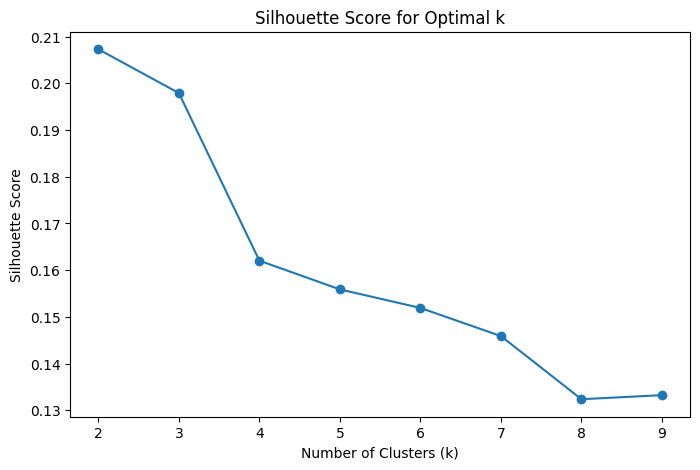

In [121]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
demo_df = pd.read_csv(os.path.join(brighten_dir, f'demographics_clean.csv'))
demo_df = demo_df.loc[:, ~demo_df.columns.str.contains('^Unnamed')]
demo_df = demo_df.select_dtypes(include=('int64','float64'))
demo_df = demo_df[[col for col in demo_df.columns if col not in skip_cols+id_columns]]
demo_df = demo_df.dropna()
silhouette_scores = []

for k in range(2, 10):  # Silhouette score works for k ≥ 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(demo_df)
    silhouette_scores.append(silhouette_score(demo_df.select_dtypes(include=('int64','float64')), labels))

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()


Run on: Fri 10 Apr 2026, 11:17AM


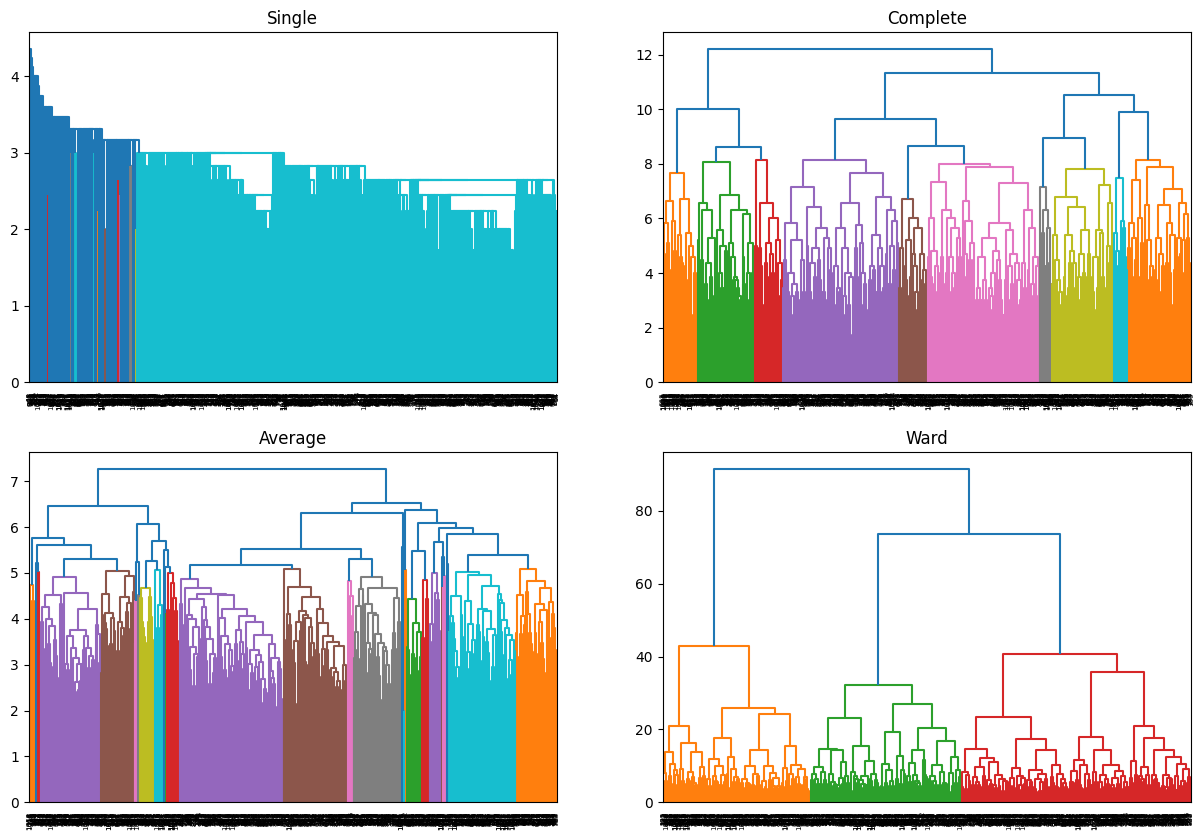

In [122]:
############# RUN A hierarchical agg clustering on averaging all VARS, V1 ##############

print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

## Plot cluster options
# Remove non-numeric columns (e.g., Participant ID)
demo_df = pd.read_csv(os.path.join(brighten_dir, f'demographics_clean.csv'))
demo_df = demo_df.loc[:, ~demo_df.columns.str.contains('^Unnamed')]
demo_df = demo_df.select_dtypes(include=('int64','float64'))
demo_df=demo_df.dropna()
demo_features = demo_df[[col for col in demo_df.columns if col not in skip_cols+id_columns]]
demo_features.to_csv(os.path.join(brighten_dir, 'demo_features.csv'), index=False)
cl.hierarchical_agg_plot(demo_features)


In [123]:
# Agglomerative clustering
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Define the model -- CHANGE based on above fits
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage="ward", metric="euclidean")

# Fit model and predict clusters
demo_features=pd.read_csv(os.path.join(brighten_dir, 'demo_features.csv'))
demo_df = pd.read_csv(os.path.join(brighten_dir, f'demographics_clean.csv'))
demo_df = demo_df.loc[:, ~demo_df.columns.str.contains('^Unnamed')]
demo_df = demo_df.select_dtypes(include=('int64','float64'))
demo_df=demo_df.dropna()
demo_df["demo_cluster"] = agg_clustering.fit_predict(demo_features)

# View cluster assignments

demo_clusters = demo_df.copy()
demo_clusters["demo_cluster"] = demo_df["demo_cluster"]
demo_clusters.value_counts()

# Save DF
demo_clusters.to_csv(os.path.join(brighten_dir, 'demo_clusters.csv'), index=False)
print('Saved demo_clusters to demo_clusters.csv')




Run on: Fri 10 Apr 2026, 11:17AM
Saved demo_clusters to demo_clusters.csv


Run on: Fri 10 Apr 2026, 11:17AM


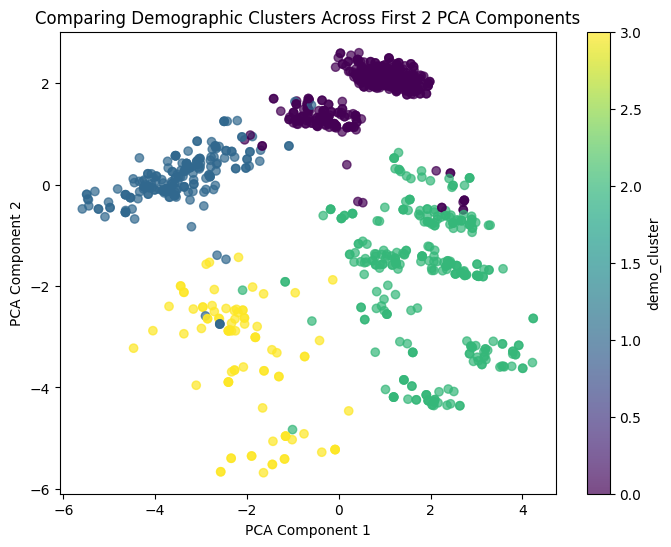

In [124]:
from sklearn.decomposition import PCA
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Reduce to 2D for visualization
demo_clusters=pd.read_csv(os.path.join(brighten_dir, 'demo_clusters.csv'))
demo_features=pd.read_csv(os.path.join(brighten_dir, 'demo_features.csv'))

pca = PCA(n_components=2)
data_pca = pca.fit_transform(demo_features)

# Scatter plot of clusters
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=demo_clusters["demo_cluster"], cmap="viridis", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Comparing Demographic Clusters Across First 2 PCA Components")
plt.colorbar(label="demo_cluster")
plt.show()


In [125]:
from scipy.stats import kruskal
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# First remove any have identical values across all clusters
demo_clusters=pd.read_csv(os.path.join(brighten_dir, 'demo_clusters.csv'))
constant_features = [col for col in demo_clusters.columns if demo_clusters[col].nunique() == 1]
print("Features with identical values across all clusters:", constant_features)

# Identify and drop features with identical values across clusters
variable_features = [col for col in demo_clusters.columns if demo_clusters[col].nunique() > 1]

# Perform Kruskal-Wallis test for each feature
kruskal_results = {
    feature: kruskal(*[demo_clusters[demo_clusters['demo_cluster'] == c][feature] for c in demo_clusters['demo_cluster'].unique()])
    for feature in variable_features
}

# Extract p-values
kruskal_pvalues = {feature: round(result.pvalue, 6) for feature, result in kruskal_results.items()}

# Convert to DataFrame for visualization
kruskal_df = pd.DataFrame.from_dict(kruskal_pvalues, orient='index', columns=['p-value'])

kruskal_df

Run on: Fri 10 Apr 2026, 11:17AM
Features with identical values across all clusters: []


,p-value
phq9_1_base,0.043787
phq9_2_base,0.034506
phq9_3_base,0.461093
phq9_4_base,0.059980
phq9_5_base,0.024191
phq9_6_base,0.026076
phq9_7_base,0.614068
phq9_8_base,0.052998
phq9_9_base,0.043007
screen_1,0.608854


In [126]:
demo_clusters=pd.read_csv(os.path.join(brighten_dir, 'demo_clusters.csv'))

demo_clusters['demo_cluster'].value_counts()

for feature in demo_clusters.columns:
    print(feature)
    print(demo_clusters.groupby('demo_cluster')[feature].count())

phq9_1_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_1_base, dtype: int64
phq9_2_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_2_base, dtype: int64
phq9_3_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_3_base, dtype: int64
phq9_4_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_4_base, dtype: int64
phq9_5_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_5_base, dtype: int64
phq9_6_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_6_base, dtype: int64
phq9_7_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_7_base, dtype: int64
phq9_8_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_8_base, dtype: int64
phq9_9_base
demo_cluster
0    453
1    205
2    297
3     87
Name: phq9_9_base, dtype: int64
screen_1
demo_cluster
0    453
1    205
2    297
3     87
Name: screen_1, dtype: int64
screen_2
demo_cluster
0    453
1    205
2    297
3     87
Name: screen_2, dt

Run on: Fri 10 Apr 2026, 11:17AM


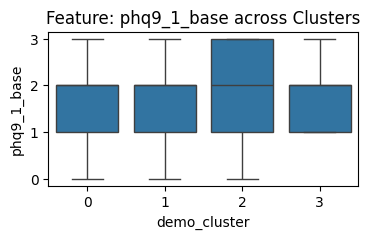

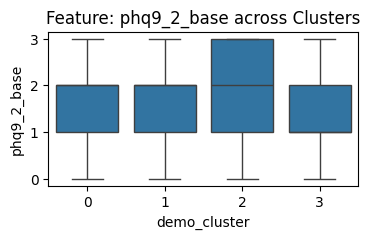

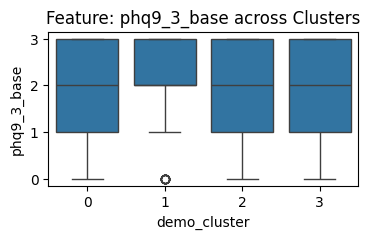

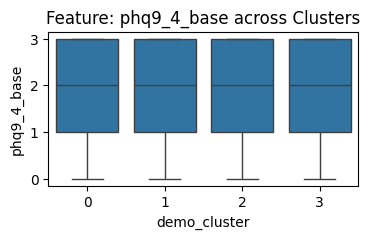

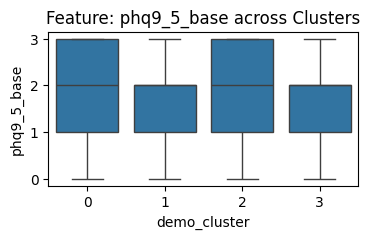

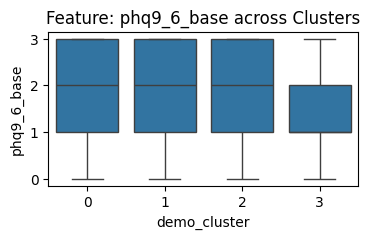

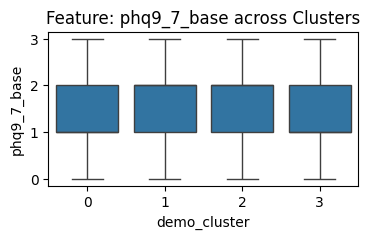

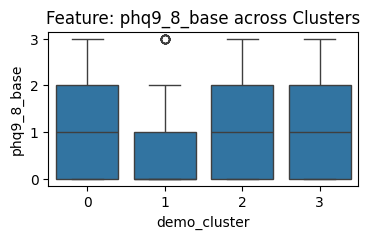

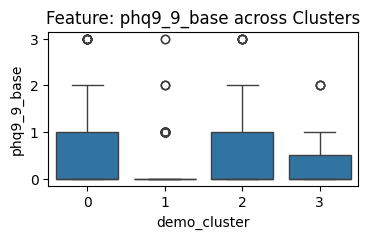

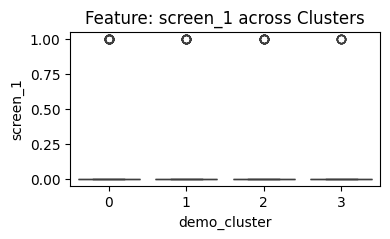

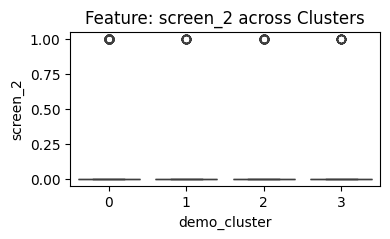

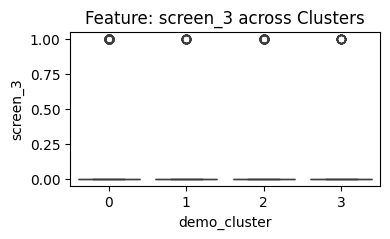

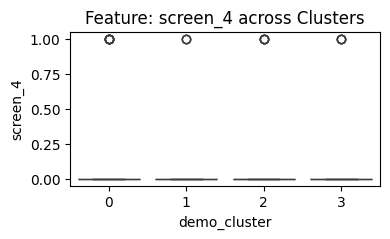

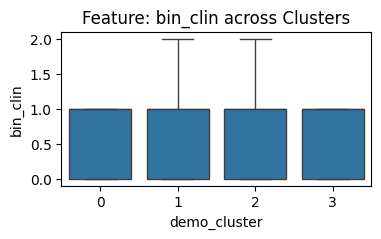

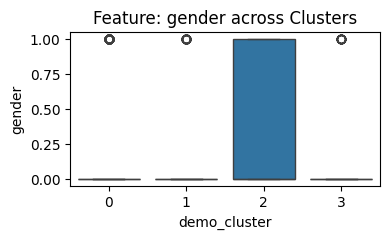

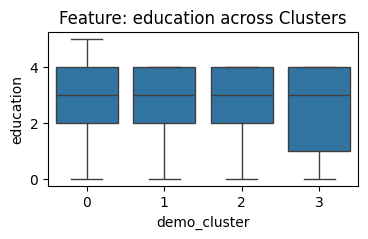

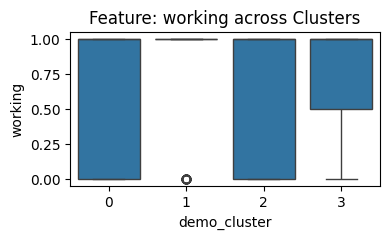

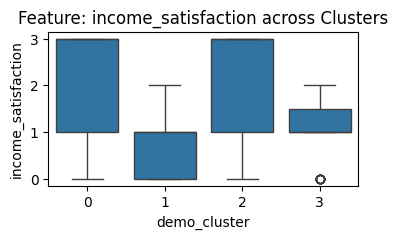

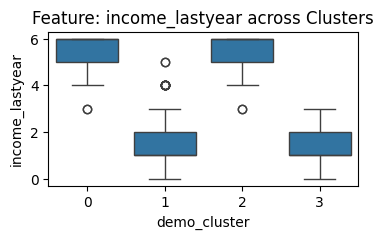

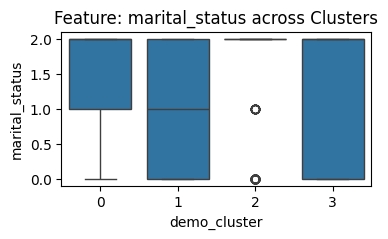

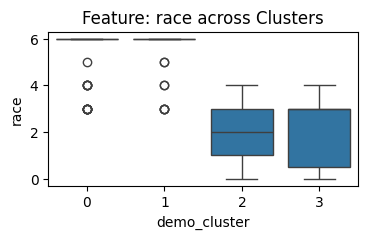

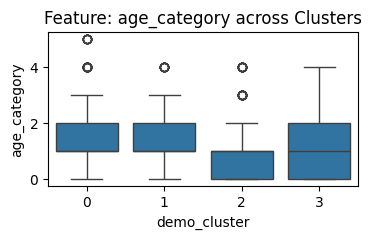

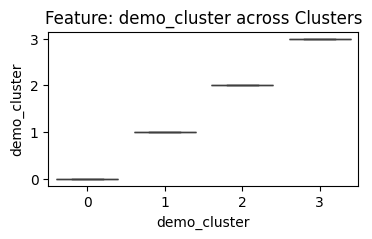

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
demo_clusters=pd.read_csv(os.path.join(brighten_dir, 'demo_clusters.csv'))

for feature in [col for col in demo_clusters.columns if col != 'num_id']:  # Check a few features
    plt.figure(figsize=(4, 2))
    sns.boxplot(x="demo_cluster", y=feature, data=demo_clusters)
    plt.title(f"Feature: {feature} across Clusters")
    plt.show()

Run on: Fri 10 Apr 2026, 11:17AM


,demo_cluster,phq9_1_base,phq9_2_base,phq9_3_base,phq9_4_base,phq9_5_base,phq9_6_base,phq9_7_base,phq9_8_base,phq9_9_base,...,screen_4,bin_clin,gender,education,working,income_satisfaction,income_lastyear,marital_status,race,age_category
0,0,2,2,2,2,2,2,1,1,0,...,0,1,0,3,1,3,6,2,6,1
1,1,2,2,2,2,2,2,2,0,0,...,0,1,0,3,1,1,1,1,6,1
2,2,2,2,2,2,2,2,2,1,0,...,0,1,0,3,1,3,6,2,2,1
3,3,2,1,2,2,2,1,1,1,0,...,0,1,0,3,1,1,1,2,3,1


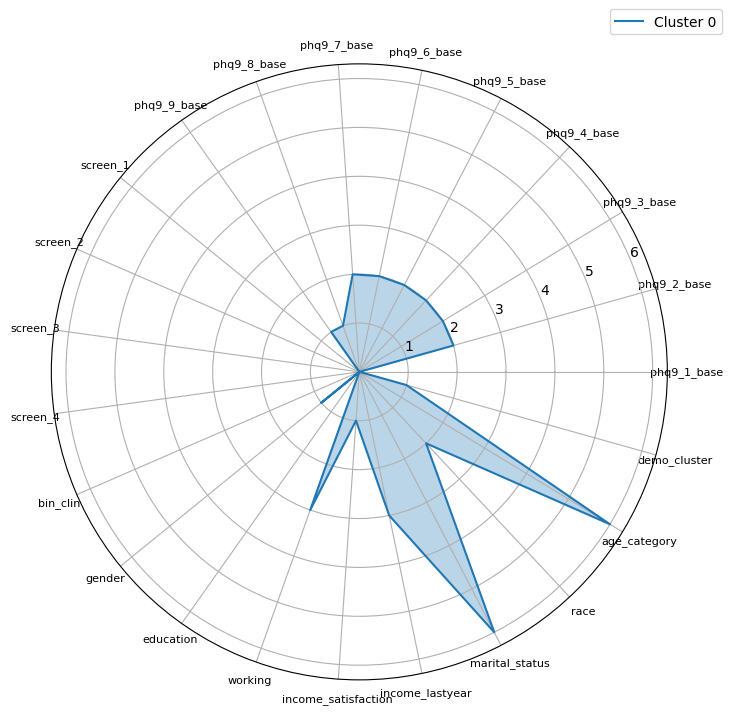

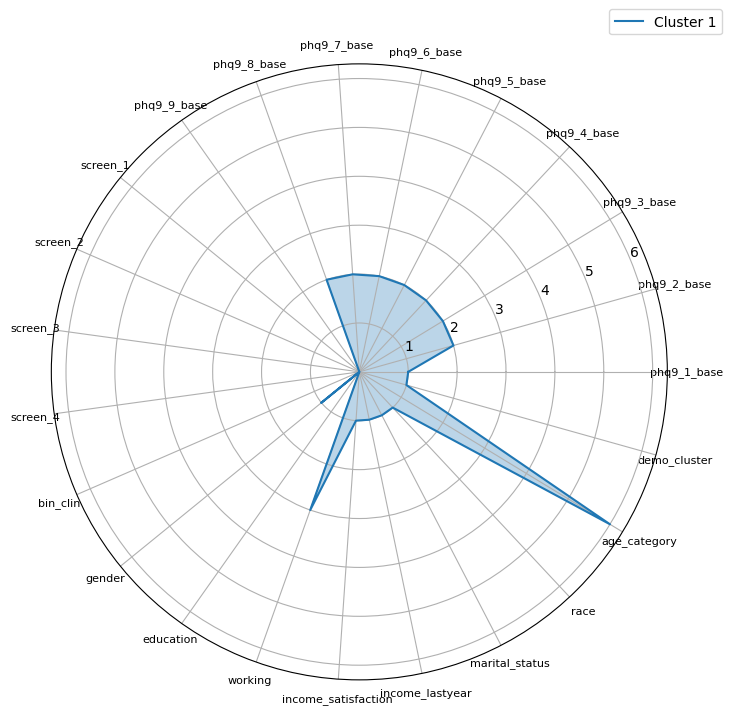

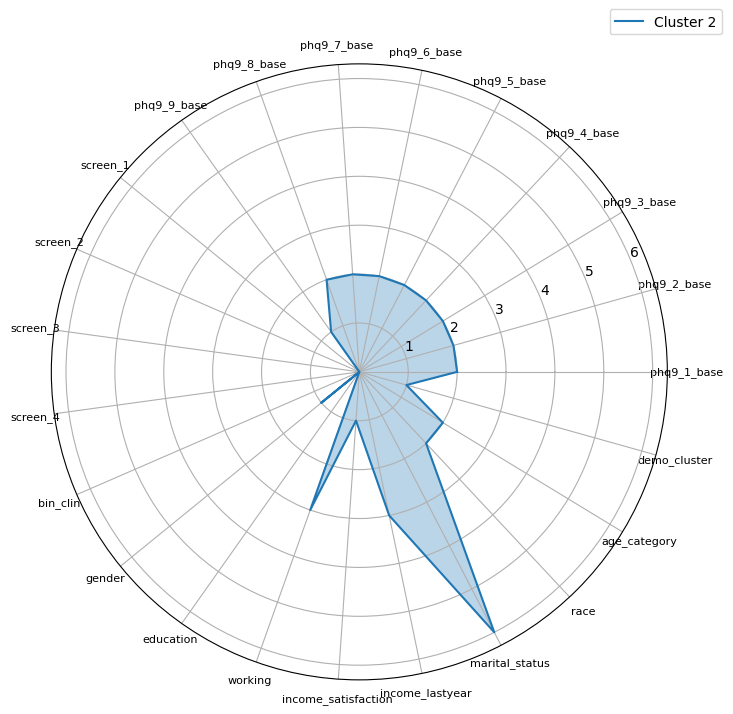

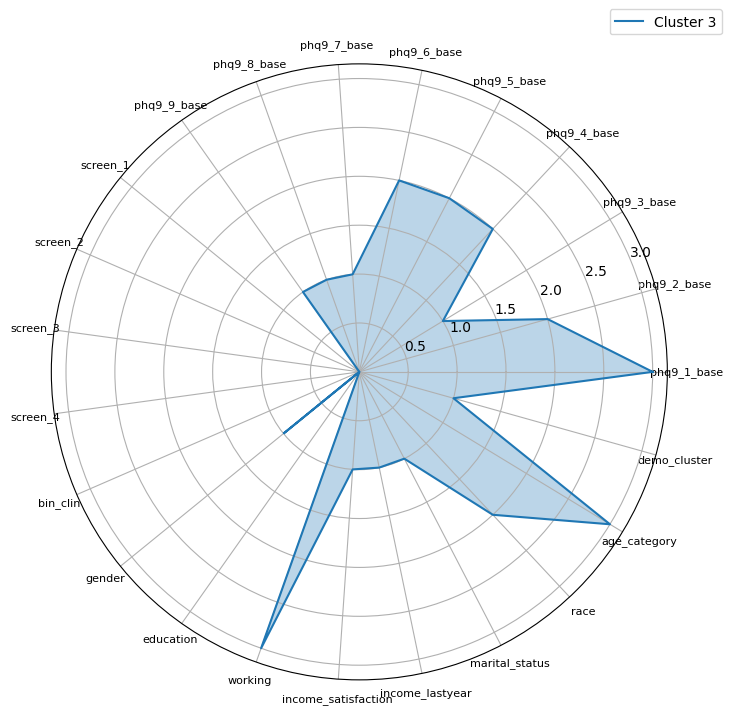

In [128]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
demo_clusters=pd.read_csv(os.path.join(brighten_dir, 'demo_clusters.csv'))

# Compute the mean of each feature for each cluster

# Force cols to numeric
for col in demo_clusters.columns:
    demo_clusters[col] = pd.to_numeric(demo_clusters[col], errors='coerce')
    
demo_clusters_without_num_id = demo_clusters.drop(columns=['num_id'])

# Compute means table
cluster_medians = demo_clusters_without_num_id.groupby("demo_cluster").median()
cluster_medians = cluster_medians.round(0).astype(int)
cluster_medians = cluster_medians.reset_index()


# Display the DataFrame in Jupyter Notebook
display(cluster_medians)


# Select key features to visualize
num_clusters = demo_clusters_without_num_id['demo_cluster'].nunique()
# Compute median values per cluster
cluster_profiles = cluster_medians.values

# Radar chart setup
angles = np.linspace(0, 2 * np.pi, len(demo_clusters_without_num_id.columns), endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# Plot each cluster separately
for i in range(num_clusters):
    values = cluster_profiles[i].tolist()
    values += values[:1]  # Close the circle

    # Create a new figure for each cluster
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, values, label=f"Cluster {i}")
    ax.fill(angles, values, alpha=0.3)

    # Label each axis
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(demo_clusters_without_num_id.columns, fontsize=8, rotation=45)

    # Show the plot
    plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1.1))
    plt.show()



In [129]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Restore original category names
cluster_means_categories = pd.DataFrame()
for col, encoder in label_encoders.items():
    if col not in cluster_medians.columns:
        print(f'Skipping {col}, not in cluster_medians.columns')
        continue
    cluster_means_categories[col] = encoder.inverse_transform(cluster_medians[col].astype(int))

# Select all columns which aren't in columns_to_scale
leftover_cols = list(set(cluster_medians.columns.to_list()).difference(cluster_means_categories.columns.to_list()))
cluster_means_categories[leftover_cols] = cluster_medians[leftover_cols]
 
display(cluster_means_categories)


Run on: Fri 10 Apr 2026, 11:17AM
Skipping participant_id, not in cluster_medians.columns


,gender,education,working,income_satisfaction,income_lastyear,marital_status,race,age_category,phq9_4_base,phq9_5_base,...,phq9_6_base,phq9_1_base,phq9_3_base,phq9_9_base,bin_clin,phq9_7_base,screen_2,phq9_2_base,screen_1,demo_cluster
0,Female,High School,Yes,NaN,NaN,Single,Non-Hispanic White,25-34,2,2,...,2,2,2,0,1,1,0,2,0,0
1,Female,High School,Yes,Can't make ends meet,"20,000-40,000",Separated/Widowed/Divorced,Non-Hispanic White,25-34,2,2,...,2,2,2,0,1,2,0,2,0,1
2,Female,High School,Yes,NaN,NaN,Single,Asian,25-34,2,2,...,2,2,2,0,1,2,0,2,0,2
3,Female,High School,Yes,Can't make ends meet,"20,000-40,000",Single,Hispanic/Latino,25-34,2,2,...,1,2,2,0,1,1,0,1,0,3
